# Quadcopter Kinematic Lyapunov Path Following with Dynamics

In this notebook, we present a symbolic derivation of a Lyapunov-based kinematic control law for a quadcopter to track a 3D trajectory (a circle at constant altitude), and simulate it using the MuJoCo engine wrapper.

In [1]:
import sys
from pathlib import Path
 
cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
 
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Math, display, Video, Image
 
from src.simulation.video_sim import VideoSim
from src.utils.config import load_config
from src.utils.plotting import set_style, FigureManager
from src.utils.animations import quadcopter_topdown, to_html5_video_with_progress
from src.symbolic.quadcopter_kinematic_lyapunov import derive_lyapunov
from src.control.cascade_controller import CascadeController, QuadState, QuadReference
from src.symbolic.quadcopter_dynamic_control import derive_allocation, derive_cascade
 
 
set_style()   # apply once at the top

This is a great addition to your notebook. Your baseline notes provide the rigorous rigid-body dynamics ($SE(3)$), but since your Python simulation and Lyapunov derivation rely on a simplified, fully actuated kinematic model, the best approach is to present **both** to show how they connect.

Here is a formatted Markdown section you can copy and paste directly into your Jupyter Notebook. It bridges your baseline notes with your controller implementation by defining both the full dynamic state-space and the reduced kinematic state-space.

---

### State-Space Representation

To formalize the vehicle's motion and bridge the gap between fundamental rigid-body dynamics and our control design, we can frame the quadcopter's equations of motion in a standard state-space formulation, $\dot{\mathbf{x}} = f(\mathbf{x}, \mathbf{u})$.

Depending on the control architecture's level of abstraction, we utilize either a full dynamic state-space model or a reduced kinematic state-space model.

#### 1. Full Dynamic State-Space Model ($SE(3)$)

Using the rigid-body dynamics detailed in the theoretical notes, the full state of the quadcopter encompasses its position, orientation, linear velocity, and angular velocity. Let the state vector be defined on the manifold $SE(3) \times \mathbb{R}^3 \times \mathbb{R}^3$:


$$\mathbf{x} = (p, R, \nu, \omega)$$

The control input vector $\mathbf{u} \in \mathbb{R}^4$ consists of the total thrust $T$ (derived from the force vector $f$) and the three control torques $\tau$:


$$\mathbf{u} = \begin{bmatrix} T \\ \tau \end{bmatrix} = \begin{bmatrix} \sum_{i=1}^{4} k \Omega_{i}^{2} \\ lk (\Omega_1^2 - \Omega_2^2 - \Omega_3^2 + \Omega_4^2) \\ lk (\Omega_1^2 + \Omega_2^2 - \Omega_3^2 + \Omega_4^2) \\ b (\Omega_1^2 - \Omega_2^2 + \Omega_3^2 - \Omega_4^2) \end{bmatrix}$$

The nonlinear state-space equations are given by:


$$\dot{p} = R\nu$$

$$\dot{R} = R S(\omega)$$

$$\dot{\nu} = -S(\omega)\nu + R^\top \bar{g} - \frac{1}{m}D_\nu(\nu)\nu + \frac{1}{m}\begin{bmatrix} 0 \\ 0 \\ T \end{bmatrix}$$

$$\dot{\omega} = -J^{-1} S(\omega) J \omega - J^{-1} D_\omega(\omega)\omega + J^{-1} \tau$$

*Note:* This model is underactuated (4 inputs for 6 degrees of freedom). As is standard in multirotor control architectures, this is handled via time-scale separation, utilizing a high-bandwidth inner-loop for attitude/dynamics and an outer-loop for position/kinematics.

#### 2. Reduced Kinematic State-Space Model

For the Lyapunov-based path-following controller derived in this notebook, we operate on the reduced-order, outer-loop kinematic model. By assuming the inner-loop attitude controller perfectly tracks our velocity and yaw commands, we can abstract away the forces and torques.

Here, the state vector $\mathbf{x} \in \mathbb{R}^4$ is simply the 3D position and the yaw angle:


$$\mathbf{x} = \begin{bmatrix} x \\ y \\ z \\ \psi \end{bmatrix}$$

The control input $\mathbf{u} \in \mathbb{R}^4$ consists of the commanded linear velocities and yaw rate:


$$\mathbf{u} = \begin{bmatrix} v_x \\ v_y \\ v_z \\ \omega_\psi \end{bmatrix}$$

The resulting kinematic state-space model is fully actuated and linear:


$$\dot{\mathbf{x}} = \mathbf{u} \implies \begin{bmatrix} \dot{x} \\ \dot{y} \\ \dot{z} \\ \dot{\psi} \end{bmatrix} = \begin{bmatrix} v_x \\ v_y \\ v_z \\ \omega_\psi \end{bmatrix}$$

This formulation serves as the direct foundation for the error dynamics $\dot{\mathbf{e}}$ and the subsequent Lyapunov stability proof simulated above.

In [2]:
"""
## Dynamic Control — Cascade Architecture
 
### Motor Allocation Matrix
 
Each motor produces a thrust $f_i \geq 0$ along the body $z$-axis and a
reaction yaw torque $\pm k_m f_i$.  The total wrench on the body is:
"""
 
alloc = derive_allocation()
 
display(Math(r"\mathbf{A} = " + sp.latex(alloc["A"])))
display(Math(r"\mathbf{A}^{-1} = " + sp.latex(alloc["A_inv"])))
display(Math(r"f_1 = " + sp.latex(sp.simplify(alloc["f1"]))))
display(Math(r"f_2 = " + sp.latex(sp.simplify(alloc["f2"]))))
display(Math(r"f_3 = " + sp.latex(sp.simplify(alloc["f3"]))))
display(Math(r"f_4 = " + sp.latex(sp.simplify(alloc["f4"]))))

<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:6: SyntaxWarning: invalid escape sequence '\g'
/var/folders/0f/blh1ts0568s3h1y6_djqxr040000gn/T/ipykernel_71871/2008549463.py:6: SyntaxWarning: invalid escape sequence '\g'
  Each motor produces a thrust $f_i \geq 0$ along the body $z$-axis and a


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
"""
### Cascade Control Law
 
**Outer loop** (Lyapunov position, same as kinematic):
"""
 
casc = derive_cascade()
 
display(Math(r"v_{x,\mathrm{cmd}} = " + sp.latex(casc["vx_cmd"])))
display(Math(r"v_{y,\mathrm{cmd}} = " + sp.latex(casc["vy_cmd"])))
display(Math(r"v_{z,\mathrm{cmd}} = " + sp.latex(casc["vz_cmd"])))
 
display(Math(r"\text{Middle loop — desired acceleration:}"))
display(Math(r"a_{x,d} = " + sp.latex(casc["ax_des"])))
display(Math(r"a_{y,d} = " + sp.latex(casc["ay_des"])))
display(Math(r"a_{z,d} = " + sp.latex(casc["az_des"])))
 
display(Math(r"\text{Thrust vector:}"))
display(Math(r"\mathbf{F}_{\mathrm{des}} = m\bigl(\mathbf{a}_{\mathrm{des}} + g\,\mathbf{e}_3\bigr)"))
display(Math(r"T = \|\mathbf{F}_{\mathrm{des}}\|"))
display(Math(r"T_{\mathrm{hover}} = " + sp.latex(casc["T_hover"])))
 
display(Math(r"""\text{Desired attitude (Lee et al., 2010):}\\
\mathbf{z}_{b,d} = \frac{\mathbf{F}_{\mathrm{des}}}{T},\quad
\mathbf{y}_{b,d} = \frac{\mathbf{z}_{b,d}\times\mathbf{x}_c}
                         {\|\mathbf{z}_{b,d}\times\mathbf{x}_c\|},\quad
\mathbf{x}_{b,d} = \mathbf{y}_{b,d}\times\mathbf{z}_{b,d}"""))
 
display(Math(r"""\text{Geometric attitude error (SO(3)):}\\
\mathbf{e}_R = \tfrac{1}{2}\,\mathrm{vee}\!\left(R_d^\top R - R^\top R_d\right),\quad
\mathbf{e}_\Omega = \boldsymbol{\Omega} - R^\top R_d\,\boldsymbol{\Omega}_d"""))
 
display(Math(r"\boldsymbol{\tau} = -k_R\,\mathbf{e}_R - k_\Omega\,\mathbf{e}_\Omega"))
 

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### LaSalle's Invariance Principle and Global Asymptotic Stability

To prove Global Asymptotic Stability (GAS) using Lyapunov theory and LaSalle's invariance principle, we look at the derivative of the Lyapunov function $\dot{V}$. 

The question is **where does $\dot{V} = 0$?**

From the derived $\dot{V}_{sub}$:
$$ \dot{V} = - k_x e_x^2 - k_y e_y^2 - k_z e_z^2 - k_\psi e_\psi^2 $$

Assuming strictly positive control gains ($k_x, k_y, k_z, k_\psi > 0$), we have $\dot{V} \le 0$ globally.
The set $E$ where $\dot{V} = 0$ is given by:

$$ E = \left\{ (e_x, e_y, e_z, e_\psi) \in \mathbb{R}^4 \mid \dot{V} = 0 \right\} = \left\{ (0, 0, 0, 0) \right\} $$

Because the error dynamics are exactly autonomous ($\dot{e}_x = -k_x e_x$, etc.), we can apply **LaSalle's Invariance Principle**:
1. $\dot{V} \le 0$ everywhere (the error states are bounded).
2. The set where $\dot{V} = 0$ contains only the origin of the error space $\mathbf{e} = 0$.
3. The largest invariant set $M$ contained in $E$ is trivially the origin.

Therefore, by LaSalle's principle, all state trajectories must converge to the largest invariant set $M$ within $E$ as $t \to \infty$. This proves that $e(t) \to 0$ globally, ensuring **Global Asymptotic Stability** of the path following scheme.

## Simulation implementation

In [4]:
config_path = str(ROOT / "config/quadcopter_lyapunov_circle.yaml")
cfg = load_config(config_path)
 
fm = FigureManager(cfg, base_dir=ROOT)
# figures will be written to  <ROOT>/<cfg['figures_dir']>/

dyn_config_path = str(ROOT / "config/quadcopter_dynamic_circle.yaml")
dyn_cfg = load_config(dyn_config_path)
 
fm_dyn = FigureManager(dyn_cfg, base_dir=ROOT)
 

"""
## Simulation
 
`QuadcopterDynamicSim` commands **real motor forces** through `data.ctrl`.
MuJoCo integrates the full 6-DOF rigid-body dynamics; nothing is written
directly to `qpos` or `qvel`.
"""
 
class QuadcopterDynamicSim(VideoSim):
 
    def __init__(self, config):
        super().__init__(config)
 
        if self.model.nq < 7 or self.model.nv < 6:
            raise RuntimeError("Model requires a free root joint (nq≥7, nv≥6).")
 
        # initial state — hovering below the target altitude
        self.data.qpos[:3]  = [0.0, 0.0, 0.5]          # start near origin, low
        self.data.qpos[3:7] = [1.0, 0.0, 0.0, 0.0]     # level attitude
        self.data.qvel[:]   = 0.0
 
        # controller
        self._ctrl = CascadeController.from_config(dyn_cfg)
 
        # trajectory parameters
        traj = dyn_cfg.get("trajectory", {})
        self.R      = traj.get("radius",   3.0)
        self.omega  = traj.get("omega",    0.5)
        self.z_d    = traj.get("z_height", 3.0)
 
        # camera
        cam = dyn_cfg.get("camera", {})
        self._cam_lookat    = np.array(cam.get("lookat",    [0.0, 0.0, 2.0]))
        self._cam_distance  = float(cam.get("distance",  12.0))
        self._cam_elevation = float(cam.get("elevation", -30.0))
        self._cam_azimuth   = float(cam.get("azimuth",   45.0))
 
    # ── reference trajectory ──────────────────────────────────────────────────
 
    def _reference(self, t: float) -> QuadReference:
        xd   =  self.R * np.cos(self.omega * t)
        yd   =  self.R * np.sin(self.omega * t)
        vxd  = -self.R * self.omega * np.sin(self.omega * t)
        vyd  =  self.R * self.omega * np.cos(self.omega * t)
        psid =  self.omega * t + np.pi / 2.0
        return QuadReference(
            pos      = np.array([xd, yd, self.z_d]),
            vel      = np.array([vxd, vyd, 0.0]),
            yaw      = psid,
            yaw_rate = self.omega,
        )
 
    # ── camera ────────────────────────────────────────────────────────────────
 
    def _capture_frame(self):
        pos = self.data.qpos[:3]
        self._camera.lookat[:]  = pos                   # track the vehicle
        self._camera.distance   = self._cam_distance
        self._camera.elevation  = self._cam_elevation
        self._camera.azimuth    = self._cam_azimuth
        self._renderer.update_scene(self.data, camera=self._camera)
        self._frames.append(self._renderer.render())
 
    # ── simulation loop ───────────────────────────────────────────────────────
 
    def _loop_step(self, t: float, step: int):
        # read full state from MuJoCo
        state = QuadState(
            pos    = self.data.qpos[:3].copy(),
            quat   = self.data.qpos[3:7].copy(),
            vel    = self.data.qvel[:3].copy(),
            angvel = self.data.qvel[3:6].copy(),
        )
 
        ref = self._reference(t)
 
        # compute motor forces via cascade controller
        forces, ctrl_log = self._ctrl.compute(state, ref)
        self.data.ctrl[:] = forces
 
        # log
        qw, qx, qy, qz = state.quat
        self.logger.log({
            "x":   float(state.pos[0]),
            "y":   float(state.pos[1]),
            "z":   float(state.pos[2]),
            "yaw": float(np.arctan2(
                2*(state.quat[0]*state.quat[3] + state.quat[1]*state.quat[2]),
                1 - 2*(state.quat[2]**2 + state.quat[3]**2)
            )),
            "xd":  float(ref.pos[0]),
            "yd":  float(ref.pos[1]),
            "zd":  float(ref.pos[2]),
            "psid": float(ref.yaw),
            "pitch": float(np.arcsin(np.clip(2*(qw*qy - qz*qx), -1.0, 1.0))),
            "roll":  float(np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))),
            **ctrl_log,
        })

        
dyn_sim = QuadcopterDynamicSim(dyn_config_path)
dyn_sim.run()
df_dyn = dyn_sim.to_dataframe()
df_dyn.tail()


Simulation: 100%|██████████| 17500/17500 [00:08<00:00, 2025.22step/s]


Video saved → /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/videos/quadcopter_dynamic_circle.mp4


,x,y,z,yaw,xd,yd,zd,psid,pitch,roll,...,eRy,eRz,tau_x,tau_y,tau_z,f1,f2,f3,f4,t
17495,0.624457,-3.103974,2.999875,0.216468,0.643677,-2.930133,3.0,19.065796,0.001447,-0.0805,...,0.012302,0.000352,-0.000071,0.000001,-3.789503e-14,1.968471,1.968278,1.968474,1.968282,34.990
17496,0.627561,-3.103348,2.999875,0.217468,0.646607,-2.929488,3.0,19.066796,0.001447,-0.0805,...,0.012302,0.000352,-0.000071,0.000001,-4.293614e-14,1.968471,1.968278,1.968474,1.968282,34.992
17497,0.630664,-3.102719,2.999875,0.218468,0.649536,-2.928840,3.0,19.067796,0.001447,-0.0805,...,0.012302,0.000352,-0.000071,0.000001,6.709217e-14,1.968471,1.968278,1.968474,1.968282,34.994
17498,0.633767,-3.102086,2.999875,0.219468,0.652465,-2.928189,3.0,19.068796,0.001447,-0.0805,...,0.012302,0.000352,-0.000071,0.000001,-2.456021e-14,1.968471,1.968278,1.968474,1.968282,34.996
17499,0.636868,-3.101451,2.999875,0.220468,0.655393,-2.927535,3.0,19.069796,0.001447,-0.0805,...,0.012302,0.000352,-0.000071,0.000001,-4.052791e-14,1.968471,1.968278,1.968474,1.968282,34.998


In [5]:
dyn_video = Path(dyn_cfg["video_path"])
if not dyn_video.is_absolute():
    dyn_video = ROOT / dyn_video
if dyn_video.exists():
    display(Video(str(dyn_video), embed=True))


  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/pitch_vs_time.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/pitch_vs_time.png


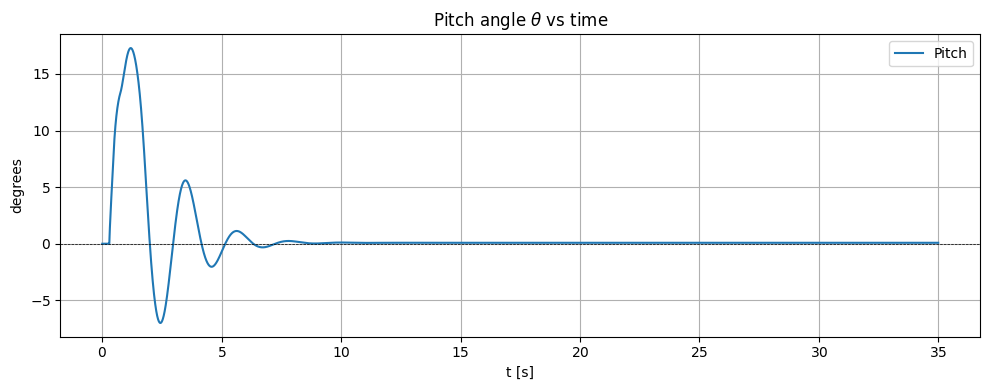

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/pitch_vs_time.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/pitch_vs_time.png')]

In [11]:
fig_pitch, ax = plt.subplots(figsize=(10, 4))

ax.plot(df_dyn["t"], np.degrees(df_dyn["pitch"]), linewidth=1.5, label="Pitch")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_title("Pitch angle $\\theta$ vs time")
ax.set_xlabel("t [s]")
ax.set_ylabel("degrees")
ax.legend()
ax.grid()

fig_pitch.tight_layout()
fm_dyn.save_and_show(fig_pitch, "pitch_vs_time")

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/motor_torques.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/motor_torques.png


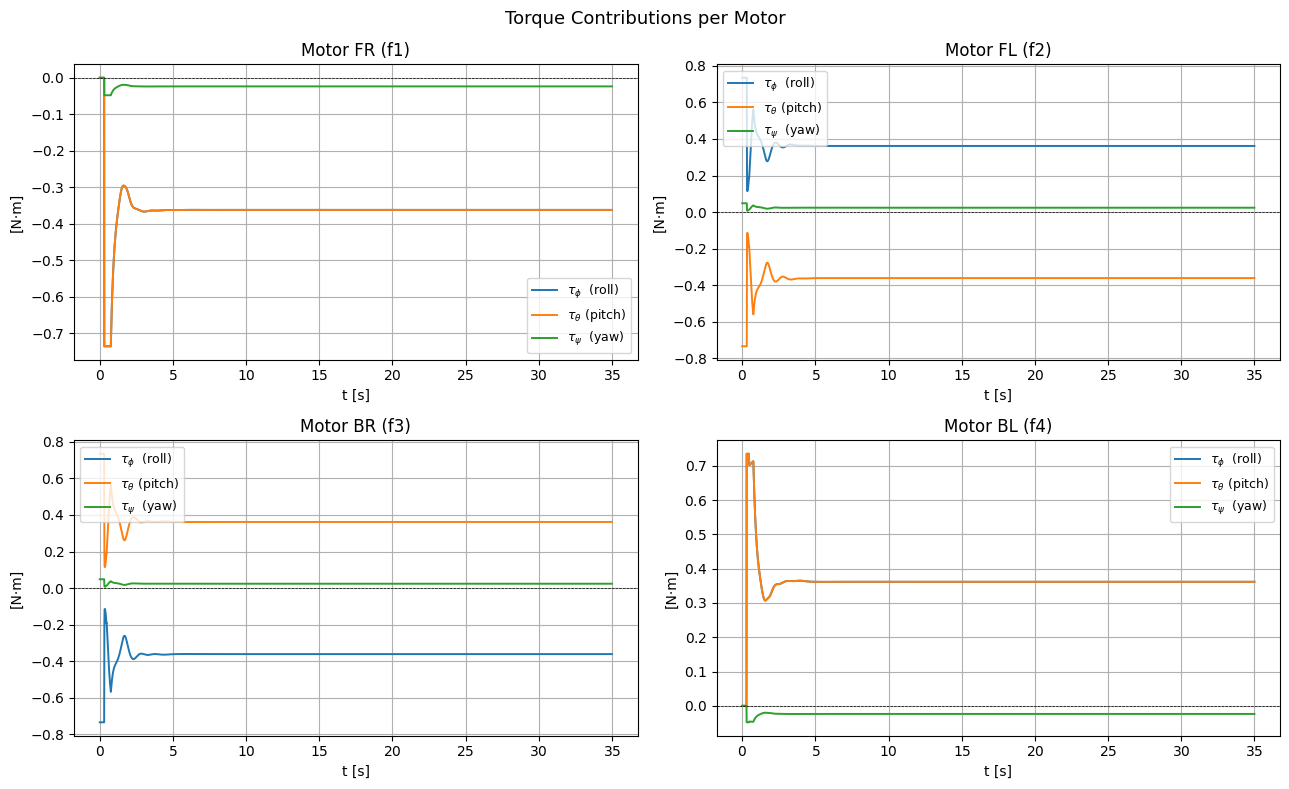

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/motor_torques.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/motor_torques.png')]

In [14]:
d  = dyn_cfg["arm_d"]
km = dyn_cfg["km"]

motors = {
    "FR (f1)": {
        "tau_roll":  -d  * df_dyn["f1"],
        "tau_pitch": -d  * df_dyn["f1"],
        "tau_yaw":   -km * df_dyn["f1"],
    },
    "FL (f2)": {
        "tau_roll":  +d  * df_dyn["f2"],
        "tau_pitch": -d  * df_dyn["f2"],
        "tau_yaw":   +km * df_dyn["f2"],
    },
    "BR (f3)": {
        "tau_roll":  -d  * df_dyn["f3"],
        "tau_pitch": +d  * df_dyn["f3"],
        "tau_yaw":   +km * df_dyn["f3"],
    },
    "BL (f4)": {
        "tau_roll":  +d  * df_dyn["f4"],
        "tau_pitch": +d  * df_dyn["f4"],
        "tau_yaw":   -km * df_dyn["f4"],
    },
}

fig_mtau, axs = plt.subplots(2, 2, figsize=(13, 8))

for ax, (motor_label, torques) in zip(axs.flat, motors.items()):
    ax.plot(df_dyn["t"], torques["tau_roll"],  label=r"$\tau_{\phi}$  (roll)",  linewidth=1.4)
    ax.plot(df_dyn["t"], torques["tau_pitch"], label=r"$\tau_{\theta}$ (pitch)", linewidth=1.4)
    ax.plot(df_dyn["t"], torques["tau_yaw"],   label=r"$\tau_{\psi}$  (yaw)",   linewidth=1.4)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_title(f"Motor {motor_label}")
    ax.set_xlabel("t [s]")
    ax.set_ylabel("[N·m]")
    ax.legend(fontsize=9)
    ax.grid()

fig_mtau.suptitle("Torque Contributions per Motor", fontsize=13)
fig_mtau.tight_layout()
fm_dyn.save_and_show(fig_mtau, "motor_torques")

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/motor_forces.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/motor_forces.png


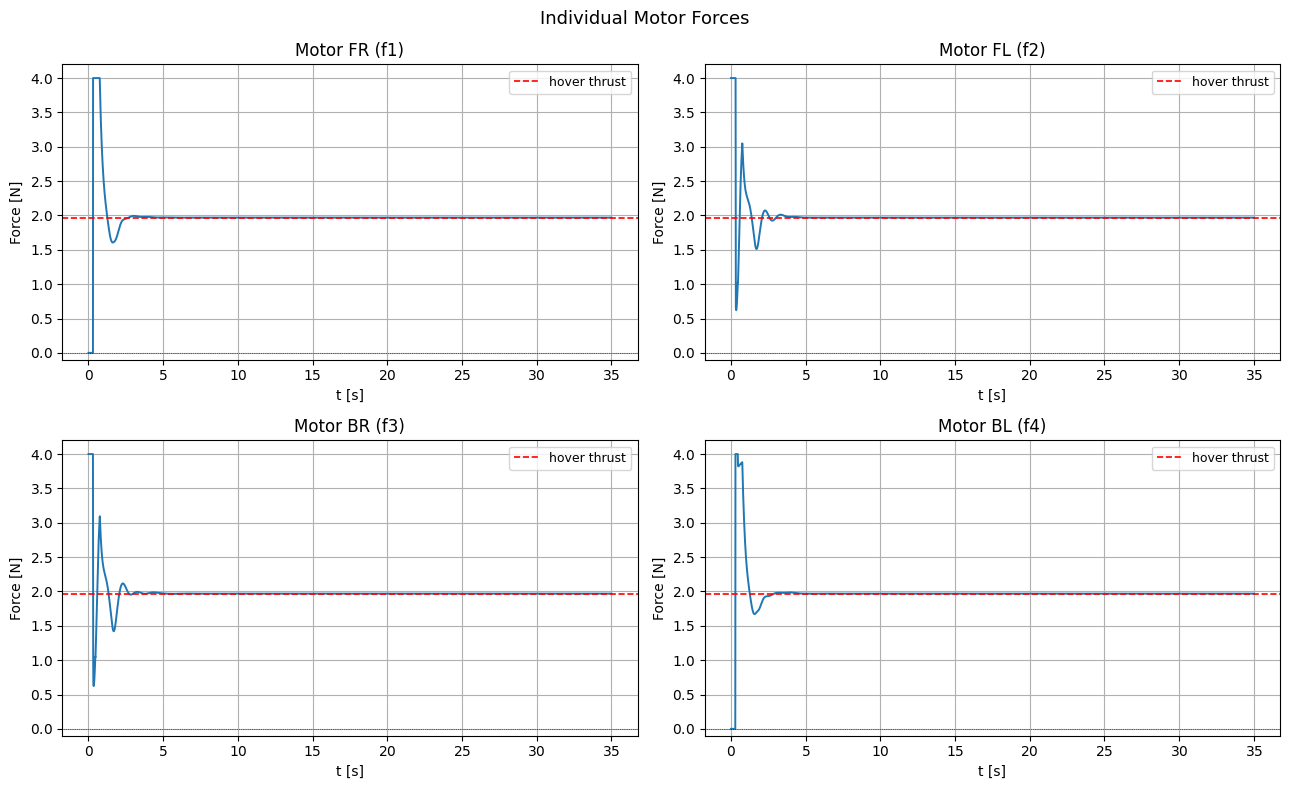

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/motor_forces.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/motor_forces.png')]

In [15]:
motors_f = {
    "FR (f1)": df_dyn["f1"],
    "FL (f2)": df_dyn["f2"],
    "BR (f3)": df_dyn["f3"],
    "BL (f4)": df_dyn["f4"],
}

fig_mf, axs = plt.subplots(2, 2, figsize=(13, 8))

for ax, (motor_label, force) in zip(axs.flat, motors_f.items()):
    ax.plot(df_dyn["t"], force, linewidth=1.4)
    ax.axhline(dyn_cfg["mass"] * 9.81 / 4, color="red",
               linestyle="--", linewidth=1.2, label="hover thrust")
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.set_title(f"Motor {motor_label}")
    ax.set_xlabel("t [s]")
    ax.set_ylabel("Force [N]")
    ax.set_ylim(-0.1, dyn_cfg["max_thrust_per_motor"] + 0.2)
    ax.legend(fontsize=9)
    ax.grid()

fig_mf.suptitle("Individual Motor Forces", fontsize=13)
fig_mf.tight_layout()
fm_dyn.save_and_show(fig_mf, "motor_forces")

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/dynamic_errors.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/dynamic_errors.png


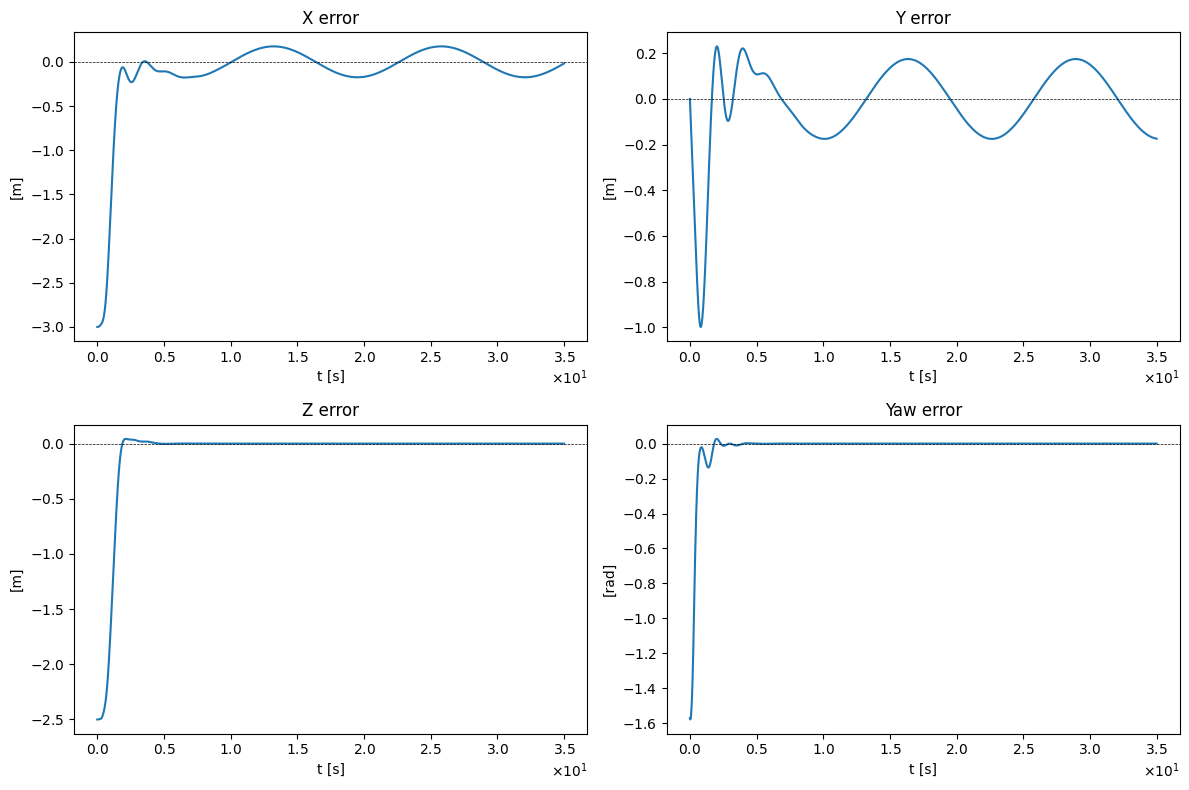

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/dynamic_errors.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/dynamic_errors.png')]

In [6]:
# fig, axs = plt.subplots(2, 2, figsize=(12, 8))
# axs[0,0].plot(df['t'], df['ex'], label='e_x')
# axs[0,0].set_title('X Error')
# axs[0,0].grid()

# axs[0,1].plot(df['t'], df['ey'], label='e_y')
# axs[0,1].set_title('Y Error')
# axs[0,1].grid()

# axs[1,0].plot(df['t'], df['ez'], label='e_z')
# axs[1,0].set_title('Z Error')
# axs[1,0].grid()

# axs[1,1].plot(df['t'], df['epsi'], label='e_psi')
# axs[1,1].set_title('Yaw Error')
# axs[1,1].grid()

# plt.tight_layout()
# plt.show()

fig_err = FigureManager.error_subplots(
    df_dyn,
    error_cols = ["ex",   "ey",   "ez",   "epsi"],
    labels     = ["X error", "Y error", "Z error", "Yaw error"],
    units      = ["m",    "m",    "m",    "rad"],
)
fm_dyn.save_and_show(fig_err, "dynamic_errors")

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/dynamic_wrench.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/dynamic_wrench.png


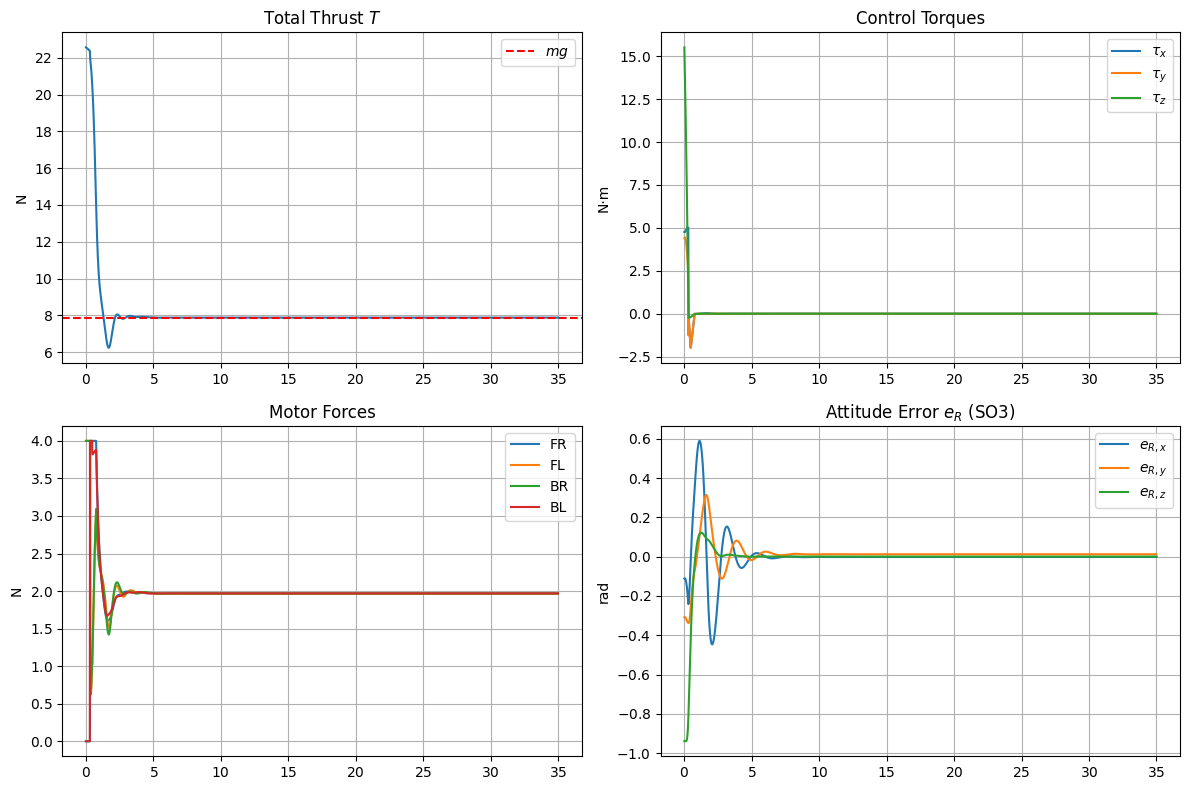

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/dynamic_wrench.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/dynamic_wrench.png')]

In [7]:

fig_wrench, axs = plt.subplots(2, 2, figsize=(12, 8))
 
axs[0,0].plot(df_dyn["t"], df_dyn["T"])
axs[0,0].set_title("Total Thrust $T$")
axs[0,0].set_ylabel("N")
axs[0,0].axhline(dyn_cfg["mass"] * 9.81, color="r", linestyle="--", label="$mg$")
axs[0,0].legend(); axs[0,0].grid()
 
axs[0,1].plot(df_dyn["t"], df_dyn["tau_x"], label=r"$\tau_x$")
axs[0,1].plot(df_dyn["t"], df_dyn["tau_y"], label=r"$\tau_y$")
axs[0,1].plot(df_dyn["t"], df_dyn["tau_z"], label=r"$\tau_z$")
axs[0,1].set_title("Control Torques"); axs[0,1].set_ylabel("N·m")
axs[0,1].legend(); axs[0,1].grid()
 
axs[1,0].plot(df_dyn["t"], df_dyn["f1"], label="FR")
axs[1,0].plot(df_dyn["t"], df_dyn["f2"], label="FL")
axs[1,0].plot(df_dyn["t"], df_dyn["f3"], label="BR")
axs[1,0].plot(df_dyn["t"], df_dyn["f4"], label="BL")
axs[1,0].set_title("Motor Forces"); axs[1,0].set_ylabel("N")
axs[1,0].legend(); axs[1,0].grid()
 
axs[1,1].plot(df_dyn["t"], df_dyn["eRx"], label=r"$e_{R,x}$")
axs[1,1].plot(df_dyn["t"], df_dyn["eRy"], label=r"$e_{R,y}$")
axs[1,1].plot(df_dyn["t"], df_dyn["eRz"], label=r"$e_{R,z}$")
axs[1,1].set_title("Attitude Error $e_R$ (SO3)"); axs[1,1].set_ylabel("rad")
axs[1,1].legend(); axs[1,1].grid()
 
fig_wrench.tight_layout()
fm_dyn.save_and_show(fig_wrench, "dynamic_wrench")
 

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/dynamic_path_3d.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/dynamic_path_3d.png


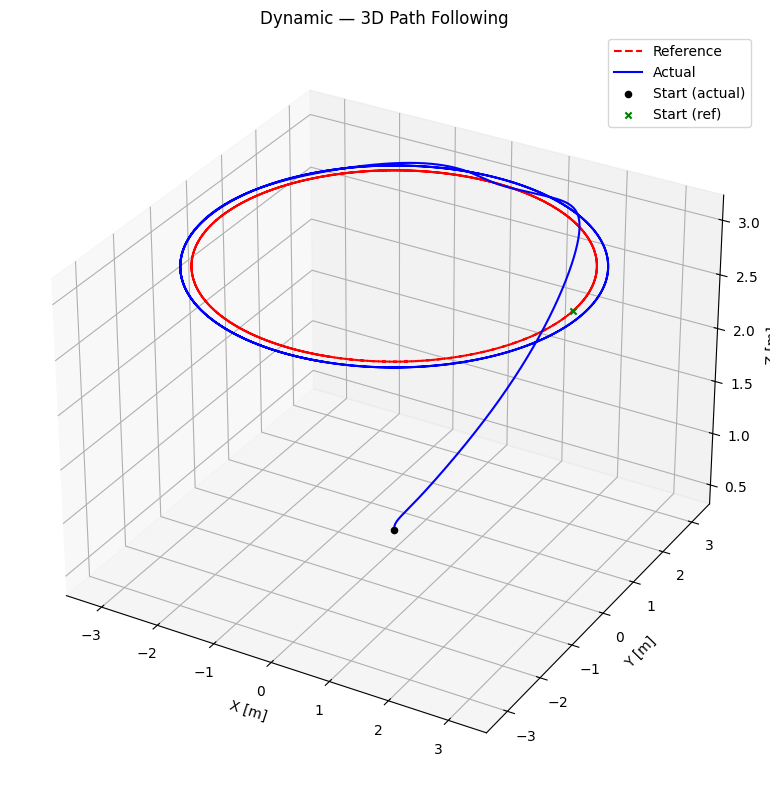

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/dynamic_path_3d.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/dynamic_path_3d.png')]

In [8]:
# fig = plt.figure(figsize=(8,8))
# ax = fig.add_subplot(111, projection='3d')

# ax.plot(df['xd'], df['yd'], df['zd'], 'r--', label='Reference')
# ax.plot(df['x'], df['y'], df['z'], 'b-', label='Actual quadcopter')

# ax.scatter([df['x'].iloc[0]], [df['y'].iloc[0]], [df['z'].iloc[0]], color='black', marker='o', label='Start Actual')
# ax.scatter([df['xd'].iloc[0]], [df['yd'].iloc[0]], [df['zd'].iloc[0]], color='green', marker='x', label='Start Ref')

# ax.set_title('3D Path Following')
# ax.set_xlabel('X [m]')
# ax.set_ylabel('Y [m]')
# ax.set_zlabel('Z [m]')
# ax.legend()
# plt.show()

fig_3d = FigureManager.path_3d(df_dyn, title="Dynamic — 3D Path Following")
fm_dyn.save_and_show(fig_3d, "dynamic_path_3d")

In [9]:
anim_dyn = quadcopter_topdown(
    df_dyn,
    dt      = dyn_cfg["dt"],
    xlim    = (-5, 5),
    ylim    = (-5, 5),
    decimate= 25,
    title   = "Dynamic — Quadcopter Top-Down View",
)
display(HTML(to_html5_video_with_progress(anim_dyn, desc="Rendering dynamic video")))
 

Rendering dynamic video: 100%|██████████| 700/700 [00:11<00:00, 63.32frame/s]


### Practical Stability (Uniform Ultimate Boundedness) under Dynamic Perturbations

Although our base Lyapunov formulation guarantees Global Asymptotic Stability (GAS) for the **kinematic** system, the position error in the **fully dynamic** simulation inevitably oscillates rather than converging to zero. This is due to the unmodeled inner-loop dynamics and the lack of reference acceleration feedforward.

We can formally prove that the cascade system exhibits **Practical Stability** (or Uniform Ultimate Boundedness, UUB).

#### 1. The Perturbed System

Let $\mathbf{e} = [e_x, e_y, e_z, e_\psi]^T$ be the outer-loop error. 
In a purely kinematic world, we commanded exactly $\mathbf{v}_{\text{cmd}}$ and achieved it instantly, leading to the nominal error dynamics:
$$ \dot{\mathbf{e}} = -K \mathbf{e} $$
where $K > 0$ is the diagonal matrix of our gains.

In the real dynamic system, the velocity achieved by the drone is delayed by the inner loop's tracking error. We can model this by adding a time-varying perturbation term $\boldsymbol{\delta}(t)$:
$$ \dot{\mathbf{e}} = -K \mathbf{e} + \boldsymbol{\delta}(t) $$

Here, $\boldsymbol{\delta}(t) \in \mathbb{R}^4$ captures the discrepancies caused by the attitude loop taking finite time to tilt the thrust vector, and the absence of a $\dot{\mathbf{v}}_{\text{cmd}}$ feedforward term to provide the exact centripetal acceleration. Assuming our inner loop is stable and bounded, $\boldsymbol{\delta}(t)$ is also bounded:
$$ \| \boldsymbol{\delta}(t) \| \le \delta_{\max} $$
*(For circular path tracking, $\delta_{\max}$ strongly depends on the circle's curvature, resulting in a persistent centripetal error).*

#### 2. Lyapunov Analysis for the Perturbed System

For the true dynamic system, we select the same Lyapunov candidate function:
$$ V(\mathbf{e}) = \frac{1}{2} \mathbf{e}^T \mathbf{e} = \frac{1}{2} \| \mathbf{e} \|^2 $$

Taking the time derivative of $V$ along the trajectories of the perturbed system:
$$ \dot{V} = \mathbf{e}^T \dot{\mathbf{e}} = \mathbf{e}^T (-K \mathbf{e} + \boldsymbol{\delta}(t)) = -\mathbf{e}^T K \mathbf{e} + \mathbf{e}^T \boldsymbol{\delta}(t) $$

Let $k_{\min} = \lambda_{\min}(K)$ be the minimum gain among $k_x, k_y, k_z, k_\psi$. Then:
$$ \dot{V} \le -k_{\min} \| \mathbf{e} \|^2 + \| \mathbf{e} \| \| \boldsymbol{\delta}(t) \| $$
$$ \dot{V} \le -k_{\min} \| \mathbf{e} \|^2 + \delta_{\max} \| \mathbf{e} \| $$

#### 3. Boundedness Condition

For the system to be stable (i.e., for the error amplitude to decrease), we require $\dot{V} < 0$. 

$$ -k_{\min} \| \mathbf{e} \|^2 + \delta_{\max} \| \mathbf{e} \| < 0 $$
$$ \| \mathbf{e} \| \left( \delta_{\max} - k_{\min} \| \mathbf{e} \| \right) < 0 $$

Since $\| \mathbf{e} \| > 0$, we divide by it to find the domain where the error shrinks:
$$ \| \mathbf{e} \| > \frac{\delta_{\max}}{k_{\min}} $$

#### Conclusion

This shows that $\dot{V}$ is strictly negative outside the ball $\mathcal{B}_r = \{\mathbf{e} \in \mathbb{R}^4 : \| \mathbf{e} \| \le r \}$ with radius:
$$ r = \frac{\delta_{\max}}{k_{\min}} $$

Therefore:
1. **Any trajectory starting outside $\mathcal{B}_r$** will strictly decrease its energy $V$ and converge towards the set $\mathcal{B}_r$.
2. **Once inside the set $\mathcal{B}_r$**, the system is no longer guaranteed to reduce its error, meaning the error can oscillate within this bounded region.

This proves that the system is **Uniformly Ultimately Bounded (UUB) / Practically Stable**. The persistent oscillation you observe is exactly the trajectory remaining trapped inside this ultimate bound $\mathcal{B}_r$ because $\delta_{\max}$ is non-zero (due to missing feedforward). To shrink the oscillation, we can either increase the positional gains ($k_{\min}$) or reduce tracking error ($\delta_{\max}$) by adding acceleration feedforward!

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

k_min      = 1.000
δ_max      = 0.2301  (steady-state, t ≥ 5.0 s)
r = δ_max / k_min = 0.2301 m  ←  UUB radius
‖e‖ at end = 0.1749 m  (should be < r)
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/practical_stability_bounds.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/practical_stability_bounds.png


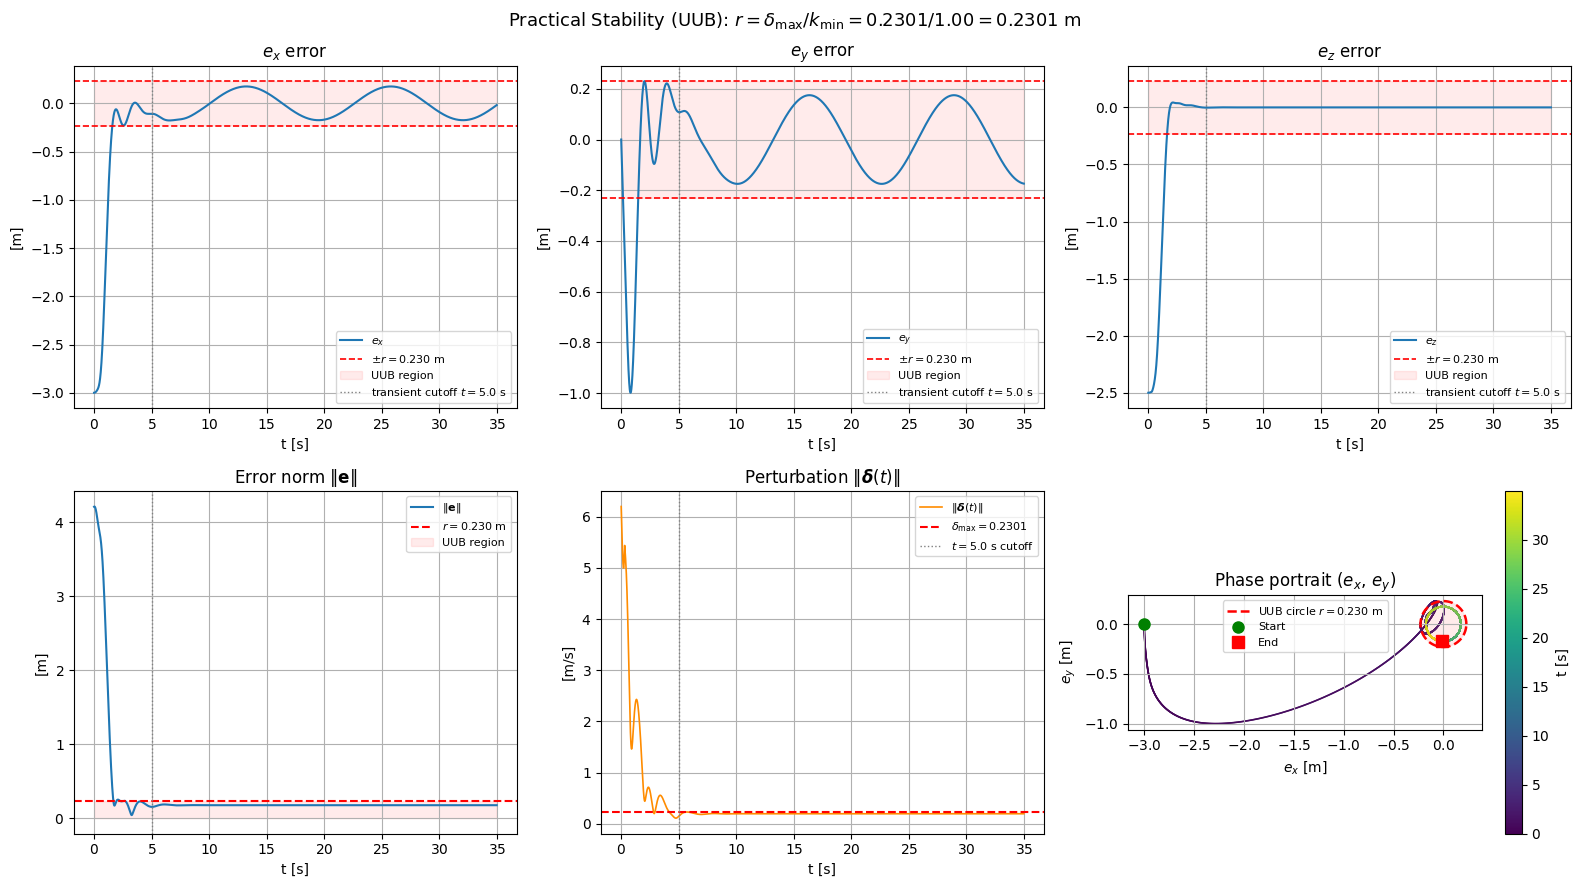

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/practical_stability_bounds.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_dynamic_circle/practical_stability_bounds.png')]

In [10]:
# ── cell: symbolic bound derivation display ───────────────────────────────────

e, k_min_s, delta_max_s, t_s = sp.symbols(r"\|\mathbf{e}\| k_{\min} \delta_{\max} t", positive=True)

V     = sp.Rational(1,2) * e**2
Vdot  = -k_min_s * e**2 + delta_max_s * e
r_sym = delta_max_s / k_min_s

display(Math(r"\text{Perturbed error dynamics:}\quad"
             r"\dot{\mathbf{e}} = -K\mathbf{e} + \boldsymbol{\delta}(t)"))
display(Math(r"\dot{V} \leq -k_{\min}\|\mathbf{e}\|^2 + \delta_{\max}\|\mathbf{e}\|"))
display(Math(r"\dot{V} < 0 \iff \|\mathbf{e}\| > r, \quad "
             r"r = \frac{\delta_{\max}}{k_{\min}} = "
             + sp.latex(r_sym)))


# ── cell: numerical bound from simulation data ────────────────────────────────

ctrl  = dyn_cfg["controller"]
k_min = min(ctrl["kx"], ctrl["ky"], ctrl["kz"], ctrl["kpsi"])

t_arr    = df_dyn["t"].values
ex_arr   = df_dyn["ex"].values
ey_arr   = df_dyn["ey"].values
ez_arr   = df_dyn["ez"].values
epsi_arr = df_dyn["epsi"].values

# Estimate perturbation: δ(t) = ė(t) + K e(t)
# ė approximated with central differences (np.gradient)
dex   = np.gradient(ex_arr,   t_arr)
dey   = np.gradient(ey_arr,   t_arr)
dez   = np.gradient(ez_arr,   t_arr)
depsi = np.gradient(epsi_arr, t_arr)

delta_x   = dex   + ctrl["kx"]   * ex_arr
delta_y   = dey   + ctrl["ky"]   * ey_arr
delta_z   = dez   + ctrl["kz"]   * ez_arr
delta_psi = depsi + ctrl["kpsi"] * epsi_arr

delta_norm = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2 + delta_psi**2)

# Use steady-state δ_max: ignore the first 5 s (transient) to get the tightest
# bound that describes the persistent oscillation
t_ss       = 5.0
ss_mask    = t_arr >= t_ss
delta_max  = float(delta_norm[ss_mask].max())
r_bound    = delta_max / k_min

# Also compute the error norm ‖e‖ at every step
e_norm = np.sqrt(ex_arr**2 + ey_arr**2 + ez_arr**2 + epsi_arr**2)

print(f"k_min      = {k_min:.3f}")
print(f"δ_max      = {delta_max:.4f}  (steady-state, t ≥ {t_ss} s)")
print(f"r = δ_max / k_min = {r_bound:.4f} m  ←  UUB radius")
print(f"‖e‖ at end = {e_norm[-1]:.4f} m  (should be < r)")


# ── cell: plots with UUB bands ────────────────────────────────────────────────

fig, axs = plt.subplots(2, 3, figsize=(16, 9))

# ── top row: individual errors with ±r band ───────────────────────────────────
for ax, arr, lbl, unit in zip(
    axs[0],
    [ex_arr, ey_arr, ez_arr],
    [r"$e_x$", r"$e_y$", r"$e_z$"],
    ["m", "m", "m"],
):
    ax.plot(t_arr, arr, linewidth=1.5, label=lbl)
    ax.axhline( r_bound, color="red",  linestyle="--", linewidth=1.2,
                label=rf"$\pm r={r_bound:.3f}$ m")
    ax.axhline(-r_bound, color="red",  linestyle="--", linewidth=1.2)
    ax.fill_between(t_arr, -r_bound, r_bound, alpha=0.08, color="red",
                    label="UUB region")
    ax.axvline(t_ss, color="grey", linestyle=":", linewidth=1.0,
               label=f"transient cutoff $t={t_ss}$ s")
    ax.set_title(f"{lbl} error")
    ax.set_xlabel("t [s]")
    ax.set_ylabel(f"[{unit}]")
    ax.legend(fontsize=8)
    ax.grid()

# ── bottom-left: ‖e‖ vs time with r line ─────────────────────────────────────
ax_norm = axs[1, 0]
ax_norm.plot(t_arr, e_norm, linewidth=1.5, label=r"$\|\mathbf{e}\|$")
ax_norm.axhline(r_bound, color="red", linestyle="--", linewidth=1.5,
                label=rf"$r = {r_bound:.3f}$ m")
ax_norm.fill_between(t_arr, 0, r_bound, alpha=0.08, color="red",
                     label="UUB region")
ax_norm.axvline(t_ss, color="grey", linestyle=":", linewidth=1.0)
ax_norm.set_title(r"Error norm $\|\mathbf{e}\|$")
ax_norm.set_xlabel("t [s]")
ax_norm.set_ylabel("[m]")
ax_norm.legend(fontsize=8)
ax_norm.grid()

# ── bottom-centre: δ(t) norm ──────────────────────────────────────────────────
ax_delta = axs[1, 1]
ax_delta.plot(t_arr, delta_norm, linewidth=1.2,
              color="darkorange", label=r"$\|\boldsymbol{\delta}(t)\|$")
ax_delta.axhline(delta_max, color="red", linestyle="--", linewidth=1.5,
                 label=rf"$\delta_{{\max}} = {delta_max:.4f}$")
ax_delta.axvline(t_ss, color="grey", linestyle=":", linewidth=1.0,
                 label=f"$t = {t_ss}$ s cutoff")
ax_delta.set_title(r"Perturbation $\|\boldsymbol{\delta}(t)\|$")
ax_delta.set_xlabel("t [s]")
ax_delta.set_ylabel("[m/s]")
ax_delta.legend(fontsize=8)
ax_delta.grid()

# ── bottom-right: 2D phase portrait (ex, ey) with UUB circle ─────────────────
ax_phase = axs[1, 2]
sc = ax_phase.scatter(ex_arr, ey_arr, c=t_arr, cmap="viridis",
                      s=1.5, linewidths=0)
fig.colorbar(sc, ax=ax_phase, label="t [s]")

theta_circ = np.linspace(0, 2*np.pi, 300)
ax_phase.plot(r_bound * np.cos(theta_circ),
              r_bound * np.sin(theta_circ),
              "r--", linewidth=1.8,
              label=rf"UUB circle $r={r_bound:.3f}$ m")
ax_phase.fill(r_bound * np.cos(theta_circ),
              r_bound * np.sin(theta_circ),
              alpha=0.08, color="red")
ax_phase.plot(ex_arr[0],  ey_arr[0],  "go", markersize=8, label="Start")
ax_phase.plot(ex_arr[-1], ey_arr[-1], "rs", markersize=8, label="End")
ax_phase.set_aspect("equal")
ax_phase.set_title(r"Phase portrait $(e_x,\, e_y)$")
ax_phase.set_xlabel(r"$e_x$ [m]")
ax_phase.set_ylabel(r"$e_y$ [m]")
ax_phase.legend(fontsize=8)
ax_phase.grid()

fig.suptitle(
    rf"Practical Stability (UUB): $r = \delta_{{\max}}/k_{{\min}}"
    rf"= {delta_max:.4f}/{k_min:.2f} = {r_bound:.4f}$ m",
    fontsize=13,
)
fig.tight_layout()
fm_dyn.save_and_show(fig, "practical_stability_bounds")